In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from census import Census

# Census Data Cleaning 

## Request Census Data

In [2]:
c = Census("c351645b7d72513154c6b11195f60f5493134e2b", year=2022)
data = c.acs5.get(
    (
        "NAME",
        "B01003_001E", # Total Population
        "B19013_001E", # Median Household Income
        "B17001_001E", # Povert Status 
        "B17001_002E", # Below poverty
        "B23025_003E", # Civilian labor force
        "B23025_005E", # Unemployed
        "B25003_001E", # Total Housing
        "B25044_003E", # Renter-occupied units with no vehicle available
        "B08301_001E", # Total commuters
        "B08301_010E"  # Commuting by public transportation
      

    ),
    {"for": "tract:*", "in": "state:36 county:*"},
)
print('done')

done


## Comfirm Census Data

In [3]:
ny_df = pd.DataFrame(data)
print(ny_df.sample(5))

                                                NAME  B01003_001E  \
1482        Census Tract 304; Kings County; New York       4150.0   
4206      Census Tract 77; Richmond County; New York       1969.0   
2508   Census Tract 5179.01; Nassau County; New York       4923.0   
4743  Census Tract 1462.06; Suffolk County; New York       1901.0   
2802  Census Tract 201.01; New York County; New York       1858.0   

      B19013_001E  B17001_001E  B17001_002E  B23025_003E  B23025_005E  \
1482      53693.0       4120.0        981.0       1846.0        111.0   
4206      89767.0       1969.0        263.0        970.0         55.0   
2508     146083.0       4909.0        222.0       2679.0        127.0   
4743     128276.0       1891.0        198.0       1178.0         74.0   
2802     151667.0        756.0        128.0       1000.0        109.0   

      B25003_001E  B25044_003E  B08301_001E  B08301_010E state county   tract  
1482       1597.0         72.0       1683.0        890.0    36    

## Rename and Recide Variables

In [4]:
# provide readable names and do any needed calculations
ny_df["total_population"] = ny_df["B01003_001E"]
ny_df["median_income"] = ny_df["B19013_001E"]
ny_df["poverty_rate"] = ny_df["B17001_002E"]/ny_df["B17001_001E"]*100
ny_df["unemployment_rate"] = ny_df["B23025_005E"]/ny_df["B23025_003E"]*100
ny_df["no_vihicle_rate"] = ny_df["B25044_003E"]/ny_df["B25003_001E"]*100

# Confirm recoded columns
print(ny_df.sample(5))

                                               NAME  B01003_001E  B19013_001E  \
2914  Census Tract 229.02; Niagara County; New York       2574.0      79068.0   
3525      Census Tract 152; Queens County; New York       2661.0      80787.0   
4908    Census Tract 1597; Suffolk County; New York       2232.0     120690.0   
5212  Census Tract 30; Westchester County; New York       2911.0      89450.0   
5093      Census Tract 710; Warren County; New York       3090.0      62148.0   

      B17001_001E  B17001_002E  B23025_003E  B23025_005E  B25003_001E  \
2914       2555.0         66.0       1582.0         50.0       1157.0   
3525       2647.0        228.0       1159.0         84.0        709.0   
4908       2221.0         77.0       1358.0         73.0        878.0   
5212       2892.0        166.0       1812.0        196.0        893.0   
5093       3090.0        280.0       1732.0         21.0       1673.0   

      B25044_003E  B08301_001E  B08301_010E state county   tract  \
2914  

In [5]:
ny_df["state"] = ny_df["state"].astype(str).str.zfill(2)
ny_df["county"] = ny_df["county"].astype(str).str.zfill(3)
ny_df["tract"] = ny_df["tract"].astype(str).str.zfill(6)

# Concatenate to form full 11-digit GEOID
ny_df["GEOID"] = ny_df["state"] + ny_df["county"] + ny_df["tract"]

In [6]:
print(ny_df.sample(5))

                                                NAME  B01003_001E  \
352         Census Tract 340; Bronx County; New York       5580.0   
2896      Census Tract 217; Niagara County; New York       3230.0   
1545        Census Tract 371; Kings County; New York       4935.0   
3003       Census Tract 251; Oneida County; New York       1891.0   
4335  Census Tract 115.09; Rockland County; New York       3728.0   

      B19013_001E  B17001_001E  B17001_002E  B23025_003E  B23025_005E  \
352       64727.0       5499.0        853.0       2700.0        159.0   
2896      42804.0       3229.0        682.0       1421.0        120.0   
1545      98281.0       4935.0        596.0       2762.0        169.0   
3003      77625.0       1890.0        163.0        864.0         22.0   
4335     107417.0       3708.0        454.0       1497.0        107.0   

      B25003_001E  B25044_003E  B08301_001E  B08301_010E state county   tract  \
352        1843.0         66.0       2524.0       1447.0    36   

# Open Street Map POIS & classification

In [7]:
nyOSM= r'C:/Users/ALIENWARE/Desktop/Machine Learning Final/new-york-latest-free.shp/gis_osm_pois_free_1.shp'
gdf_nyOSM = gpd.read_file(nyOSM)
gdf_nyOSM["fclass"].unique()

array(['camera_surveillance', 'bench', 'park', 'guesthouse', 'attraction',
       'school', 'viewpoint', 'beverages', 'beauty_shop', 'tourist_info',
       'museum', 'bar', 'lighthouse', 'dentist', 'police', 'restaurant',
       'fire_station', 'memorial', 'tower', 'market_place', 'ruins',
       'hotel', 'toilet', 'fast_food', 'convenience', 'pub', 'pharmacy',
       'bicycle_shop', 'clothes', 'cafe', 'water_tower', 'drinking_water',
       'shelter', 'bank', 'doityourself', 'kindergarten', 'laundry',
       'furniture_shop', 'jeweller', 'theatre', 'hairdresser',
       'garden_centre', 'sports_shop', 'doctors', 'supermarket', 'clinic',
       'post_office', 'recycling_glass', 'car_dealership', 'library',
       'college', 'graveyard', 'community_centre', 'pitch', 'university',
       'monument', 'playground', 'sports_centre', 'picnic_site', 'prison',
       'hospital', 'theme_park', 'battlefield', 'comms_tower',
       'observation_tower', 'post_box', 'artwork', 'town_hall',
       '

In [8]:
food_fclass = ['restaurant', 'cafe', 'fast_food', 'bakery', 'butcher', 'greengrocer',
    'pub', 'bar', 'food_court']

# Filter the GeoDataFrame to include only those POIs
pois_food = gdf_nyOSM[gdf_nyOSM["fclass"].isin(food_fclass)].copy()

# Check how many and what types
print(pois_food["fclass"].value_counts())
print(f"Total filtered POIs: {len(pois_food)}")

fclass
restaurant     11684
fast_food       5783
cafe            3202
bar             1808
bakery           891
pub              586
greengrocer      211
butcher          191
food_court        70
Name: count, dtype: int64
Total filtered POIs: 24426


In [9]:
pois_food[["name", "fclass"]].dropna().head(10)

,name,fclass
14,Seebers Tavern,bar
19,Griffon Gastropub,restaurant
20,"Tony Rome's ""The Globe""",restaurant
21,Rick's on Main,restaurant
22,East End Tap Room,restaurant
23,Leo's Pizzeria,restaurant
62,Jim's Steak Out,fast_food
64,Allen Street Hardware,restaurant
65,Crust Pizza Bar,restaurant
66,Falley Allen,restaurant


In [10]:
name_counts = pois_food["name"].value_counts()
chain_brand = name_counts[name_counts>1].index.tolist()
pois_food["biz_type"] = pois_food["name"].apply(
    lambda x: "chain" if x in chain_brand else "independent"
)
print(pois_food["biz_type"].value_counts())

biz_type
independent    17189
chain           7237
Name: count, dtype: int64


In [11]:
pois_food[["name","fclass","biz_type"]].sample(5)

,name,fclass,biz_type
77685,Bokki,fast_food,independent
94741,Kong Fu Tea,cafe,independent
67022,Saketumi Asian Bistro,restaurant,independent
20935,None,fast_food,independent
70240,N25 Nitro Tea & Coffee,cafe,independent


# GeoMapping of NYC

In [12]:
nyct2020 = r'C:/Users/ALIENWARE/Desktop/Machine Learning Final/nyct2020_25a/nyct2020.shp'
gdf_nyct2020 = gpd.read_file(nyct2020)
print(gdf_nyct2020.columns)

Index(['CTLabel', 'BoroCode', 'BoroName', 'CT2020', 'BoroCT2020', 'CDEligibil',
       'NTAName', 'NTA2020', 'CDTA2020', 'CDTANAME', 'GEOID', 'PUMA',
       'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object')


In [13]:
gdf_nyct2020["BoroCode"] = gdf_nyct2020["BoroCode"].astype(int)

In [14]:
# nyct_ny = gdf_nyct2020[gdf_nyct2020["BoroCode"].isin([1,2,3,4,5])].copy()

In [15]:
nyct_ny = gdf_nyct2020[gdf_nyct2020["BoroCode"]== 3].copy()

In [16]:
print(len(nyct_ny))

804


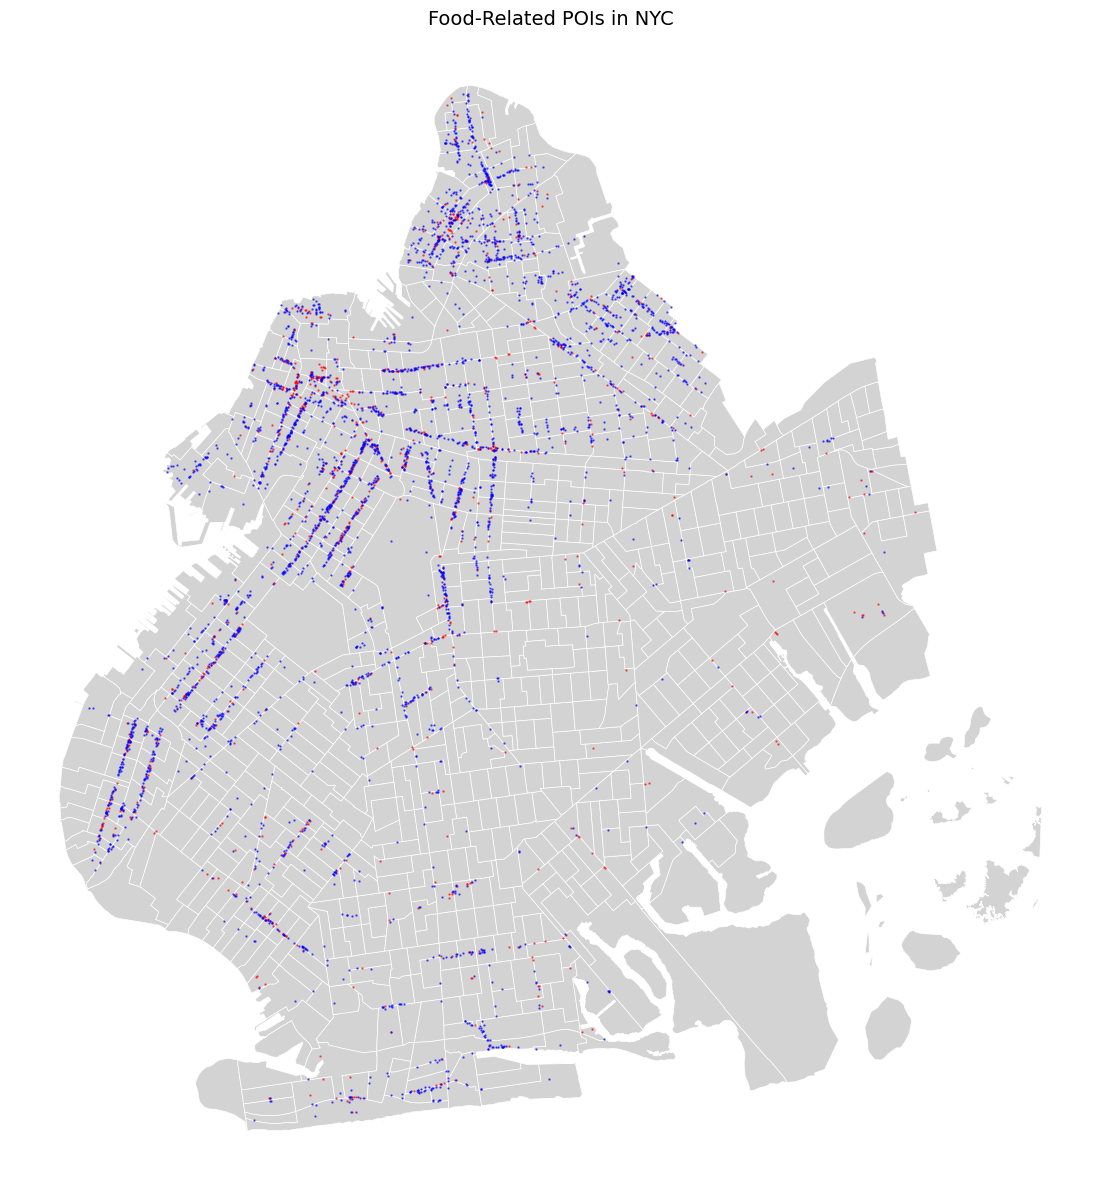

In [17]:
pois_food = pois_food.to_crs(nyct_ny.crs)
pois_nyc = gpd.sjoin(pois_food, nyct_ny, predicate="within", how="inner")

fig, ax = plt.subplots(figsize=(15, 15))

nyct_ny.plot(ax=ax, edgecolor="white", facecolor="lightgrey", linewidth=0.5)

pois_nyc[pois_nyc["biz_type"] == "chain"].plot(
    ax=ax, color="red", markersize=0.5, label="Chain", alpha=0.6)

pois_nyc[pois_nyc["biz_type"] == "independent"].plot(
    ax=ax, color="blue", markersize=0.5, label="Independent", alpha=0.6)

# legend_patches = [
    #mpatches.Patch(color=color, label=label.replace("_", " ").title())
    #for label, color in label_colors.items()
#]

# plt.legend(handles=legend_patches, title="Business Pattern Zone")

plt.title("Food-Related POIs in NYC", fontsize=14)
plt.axis("off")
plt.show()

# Chain & Independent food store hotspot in Brooklyn

(-8242306.227665067, -8219114.217918726, 4949053.287479814, 4973938.911578707)

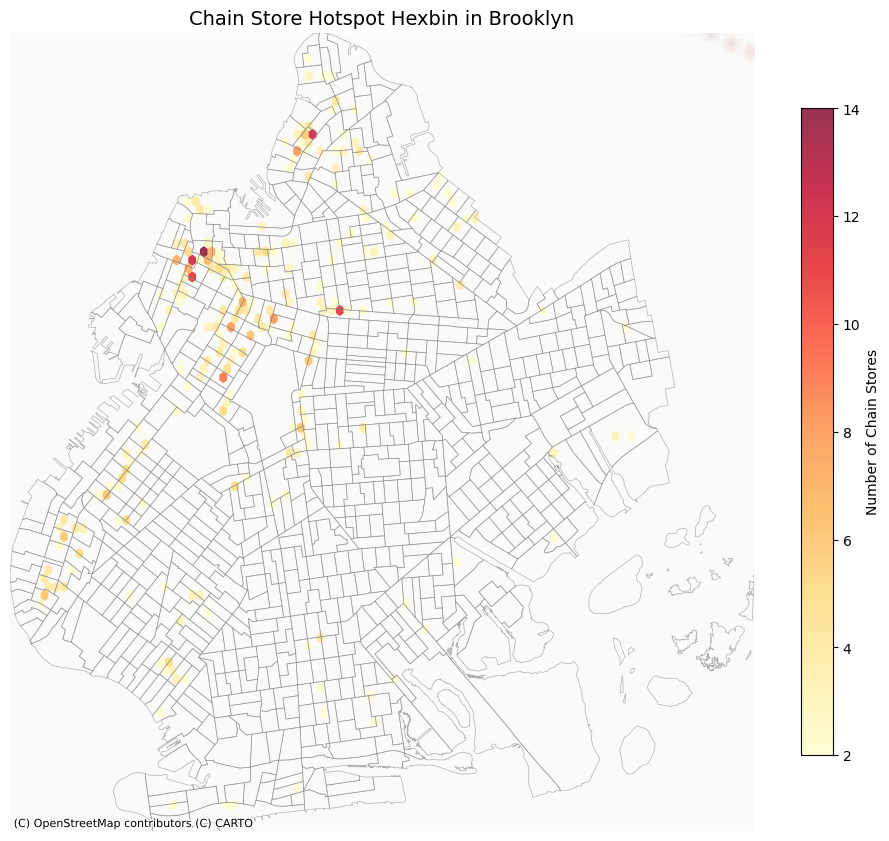

In [39]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

nyct_ny = nyct_ny.to_crs(epsg=2263)

brooklyn = nyct_ny[nyct_ny["BoroCode"] == 3].copy()

# Filter and project data
pois_chain = pois_food[pois_food["biz_type"] == "chain"]
pois_indie = pois_food[pois_food["biz_type"] == "independent"]

# Project to web mercator for consistent plotting (EPSG 3857)
brooklyn_proj = brooklyn.to_crs(epsg=3857)
pois_chain_proj = pois_chain.to_crs(epsg=3857)

pois_chain_bk = gpd.sjoin(pois_chain_proj, brooklyn_proj, predicate="within", how="inner")

# Hexbin: Chain Stores
x = pois_chain_bk.geometry.x
y = pois_chain_bk.geometry.y

fig, ax = plt.subplots(figsize=(12, 12))
hb = ax.hexbin(x, y, gridsize=80, cmap="YlOrRd", edgecolors='none', mincnt=2, alpha=0.8)

# 4. Add NYC boundary for reference
brooklyn_proj.boundary.plot(ax=ax, linewidth=0.5, edgecolor='grey', alpha=0.6)

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=brooklyn.crs.to_string(), zoom=11)

cb = fig.colorbar(hb, ax=ax, shrink=0.7, label="Number of Chain Stores")


# 6. Format plot
minx, miny, maxx, maxy = brooklyn_proj.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("Chain Store Hotspot Hexbin in Brooklyn", fontsize=14, color="black")
plt.axis("off")

(-8242306.227665068, -8219114.217918727, 4949053.287479813, 4973938.911578707)

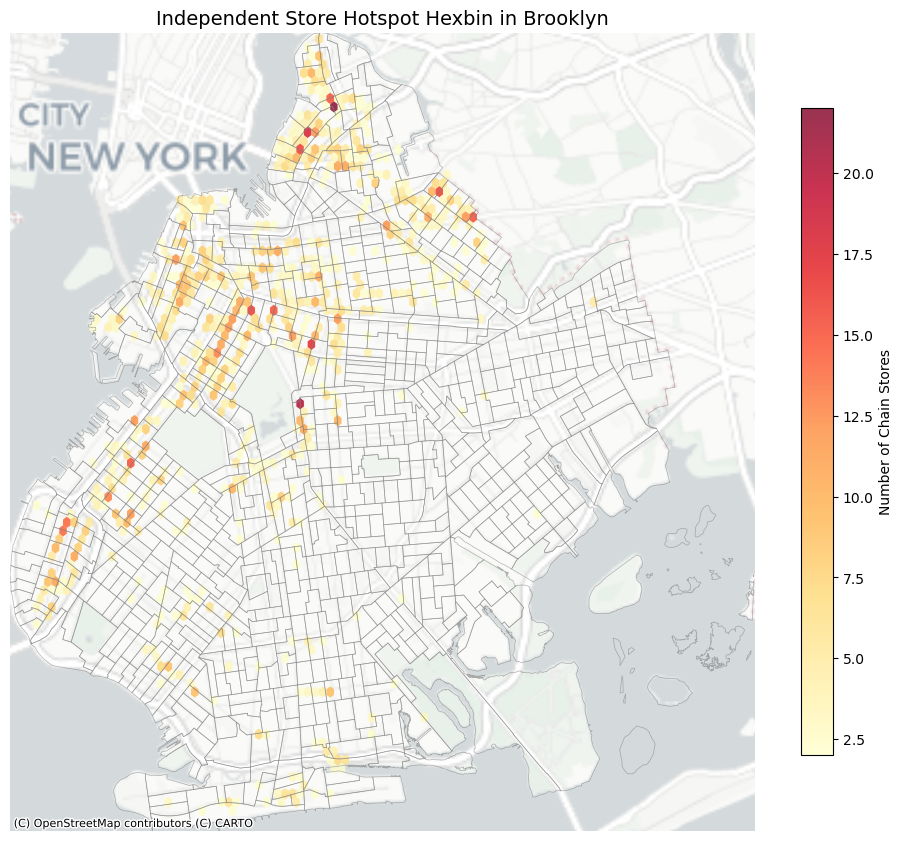

In [38]:
pois_indie = pois_food[pois_food["biz_type"] == "independent"]

# Project to web mercator for consistent plotting (EPSG 3857)
brooklyn_proj = brooklyn.to_crs(epsg=3857)
pois_indie_proj = pois_indie.to_crs(epsg=3857)

pois_indie_bk = gpd.sjoin(pois_indie_proj, brooklyn_proj, predicate="within", how="inner")

# Hexbin: Chain Stores
x = pois_indie_bk.geometry.x
y = pois_indie_bk.geometry.y

fig, ax = plt.subplots(figsize=(12, 12))
hb = ax.hexbin(x, y, gridsize=80, cmap="YlOrRd", edgecolors='none', mincnt=2, alpha=0.8)

# 4. Add NYC boundary for reference
brooklyn_proj.boundary.plot(ax=ax, linewidth=0.5, edgecolor='grey', alpha=0.6)

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=brooklyn.crs.to_string(), zoom=11)

cb = fig.colorbar(hb, ax=ax, shrink=0.7, label="Number of Chain Stores")


# 6. Format plot
minx, miny, maxx, maxy = brooklyn_proj.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("Independent Store Hotspot Hexbin in Brooklyn", fontsize=14, color="black")
plt.axis("off")

# Combine Census Tract data and POIS

## For Food Store POIS

In [19]:
ny_df["GEOID"] = ny_df["GEOID"].astype(str)
nyct_ny["GEOID"] = nyct_ny["GEOID"].astype(str)

nyc_geo = nyct_ny.merge(ny_df, on="GEOID", how="left")

In [20]:
tract_summary = pois_nyc.groupby("GEOID").agg(
    total_pois=("name", "count"),
    chain_count=("biz_type", lambda x: (x == "chain").sum()),
    indie_count=("biz_type", lambda x: (x == "independent").sum())
).reset_index()

# Add % chain and % indie
tract_summary["pct_chain"] = tract_summary["chain_count"] / tract_summary["total_pois"]*100
tract_summary["pct_indie"] = tract_summary["indie_count"] / tract_summary["total_pois"]*100

tract_summary["pct_chain"] = tract_summary["pct_chain"].round(2)
tract_summary["pct_indie"] = tract_summary["pct_indie"].round(2)
nyc_pois_new = tract_summary.merge(nyc_geo, on="GEOID")

In [40]:
nyc_pois_new.sample(10)

,GEOID,total_pois,chain_count,indie_count,pct_chain,pct_indie,CTLabel,BoroCode,BoroName,CT2020,...,B08301_001E,B08301_010E,state,county,tract,total_population,median_income,poverty_rate,unemployment_rate,no_vihicle_rate
169,36047022900,9,1,8,11.11,88.89,229,3,Brooklyn,022900,...,2272.0,1162.0,36,047,022900,3490.0,121997.0,13.038484,6.582175,11.810513
100,36047013800,16,4,12,25.00,75.00,138,3,Brooklyn,013800,...,1537.0,796.0,36,047,013800,3670.0,93117.0,8.301475,13.077351,3.421462
407,36047057600,1,1,0,100.00,0.00,576,3,Brooklyn,057600,...,1425.0,687.0,36,047,057600,2905.0,81711.0,12.215321,4.324684,26.482213
323,36047044902,4,0,4,0.00,100.00,449.02,3,Brooklyn,044902,...,0.0,0.0,36,047,044902,0.0,-666666666.0,NaN,NaN,NaN
442,36047069602,1,0,1,0.00,100.00,696.02,3,Brooklyn,069602,...,2682.0,1252.0,36,047,069602,5220.0,90917.0,9.906112,0.900901,12.180143
503,36047119800,3,2,1,66.67,33.33,1198,3,Brooklyn,119800,...,1301.0,782.0,36,047,119800,3851.0,39940.0,42.865029,9.569685,10.181191
208,36047028400,12,4,9,33.33,75.00,284,3,Brooklyn,028400,...,1313.0,564.0,36,047,028400,3328.0,58373.0,19.350962,5.339806,2.579219
32,36047005302,6,0,6,0.00,100.00,53.02,3,Brooklyn,005302,...,41.0,4.0,36,047,005302,93.0,129659.0,4.301075,0.000000,0.000000
36,36047005602,4,1,3,25.00,75.00,56.02,3,Brooklyn,005602,...,948.0,436.0,36,047,005602,1730.0,97750.0,3.121387,1.349948,21.530055
304,36047042600,5,0,5,0.00,100.00,426,3,Brooklyn,042600,...,2163.0,1123.0,36,047,042600,4981.0,77500.0,30.097087,10.425184,7.386364


In [41]:
nyc_pois_new.to_csv('C:/Users/ALIENWARE/Desktop/Machine Learning Final/nyc_pois_new.csv')

## For Land Use POIS

In [42]:
nyOSM_landuse= r'C:/Users/ALIENWARE/Desktop/Machine Learning Final/new-york-latest-free.shp/gis_osm_landuse_a_free_1.shp'
landuse = gpd.read_file(nyOSM_landuse)
landuse["fclass"].unique()

array(['forest', 'grass', 'scrub', 'nature_reserve', 'heath', 'park',
       'cemetery', 'retail', 'industrial', 'commercial', 'residential',
       'recreation_ground', 'quarry', 'farmland', 'meadow', 'military',
       'allotments', 'orchard', 'farmyard', 'vineyard'], dtype=object)

In [43]:
landuse.columns

Index(['osm_id', 'code', 'fclass', 'name', 'geometry'], dtype='object')

In [44]:
def simplify_landuse(fclass):
    if fclass in ["residential"]:
        return "Residential"
    elif fclass in ["retail", "commercial"]:
        return "Commercial"
    elif fclass in ["industrial", "quarry"]:
        return "Industrial"
    elif fclass in ["park", "recreation_ground", "cemetery", "allotments", "nature_reserve", "heath"]:
        return "Open_Space"
    elif fclass in ["farmland", "meadow", "orchard", "farmyard", "vineyard"]:
        return "Agricultural"
    elif fclass in ["grass", "scrub", "forest"]:
        return "Natural"
    elif fclass in ["military"]:
        return "Institutional"
    else:
        return "Other"

landuse["landuse_simple"] = landuse["fclass"].apply(simplify_landuse)
landuse["landuse_simple"].unique()

array(['Natural', 'Open_Space', 'Commercial', 'Industrial', 'Residential',
       'Agricultural', 'Institutional'], dtype=object)

In [45]:
nyc_pois_new

,GEOID,total_pois,chain_count,indie_count,pct_chain,pct_indie,CTLabel,BoroCode,BoroName,CT2020,...,B08301_001E,B08301_010E,state,county,tract,total_population,median_income,poverty_rate,unemployment_rate,no_vihicle_rate
0,36047000100,22,3,19,13.64,86.36,1,3,Brooklyn,000100,...,2731.0,1206.0,36,047,000100,4974.0,165188.0,4.573973,4.188122,22.101590
1,36047000200,14,2,12,14.29,85.71,2,3,Brooklyn,000200,...,618.0,349.0,36,047,000200,1170.0,78942.0,26.153846,7.500000,3.399433
2,36047000301,3,2,1,66.67,33.33,3.01,3,Brooklyn,000301,...,2219.0,1010.0,36,047,000301,4057.0,193158.0,3.758829,2.440087,17.603393
3,36047000501,9,2,7,22.22,77.78,5.01,3,Brooklyn,000501,...,2271.0,742.0,36,047,000501,4432.0,140795.0,6.352143,4.592241,37.110187
4,36047000502,13,4,9,30.77,69.23,5.02,3,Brooklyn,000502,...,1596.0,844.0,36,047,000502,2774.0,169313.0,4.286770,6.172840,28.766190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,36047120803,1,1,0,100.00,0.00,1208.03,3,Brooklyn,120803,...,1175.0,412.0,36,047,120803,1951.0,72451.0,9.075440,0.927487,3.880071
506,36047122000,2,1,1,50.00,50.00,1220,3,Brooklyn,122000,...,2630.0,1305.0,36,047,122000,7200.0,57055.0,21.291667,5.928293,0.000000
507,36047123700,6,0,6,0.00,100.00,1237,3,Brooklyn,123700,...,1716.0,170.0,36,047,123700,9448.0,51157.0,48.592295,4.347826,9.756098
508,36047150200,2,0,2,0.00,100.00,1502,3,Brooklyn,150200,...,1212.0,546.0,36,047,150200,2730.0,128472.0,2.380952,3.356753,15.829384


In [46]:
# Match CRS
landuse = landuse.to_crs(nyct_ny.crs)

# Spatial join: clip land use polygons to each tract
landuse_bk = gpd.overlay(landuse, nyct_ny, how="intersection")

# Calculate area of each clipped land use polygon
landuse_bk = gpd.sjoin(landuse_bk, nyct_ny, how='inner', predicate='intersects')
landuse_bk["landuse_area"] = landuse_bk.geometry.area

# 5. Pivot to get area sum per land use category per tract
landuse_summary = landuse_bk.pivot_table(
    index='index_right',  # or a unique census tract ID
    columns='landuse_simple',     # land use category
    values='landuse_area',
    aggfunc='sum',
    fill_value=0
)

# Optional: Normalize by total area per tract
landuse_summary = landuse_summary.div(landuse_summary.sum(axis=1), axis=0)

In [47]:
landuse_summary.sample(10)

landuse_simple,Agricultural,Commercial,Industrial,Institutional,Natural,Open_Space,Residential
index_right,,,,,,,
2089,0.000000,0.0,0.000000,0.000000,0.206363,0.793637,0.000000
1475,0.000000,0.0,0.000000,0.000000,0.024985,0.975015,0.000000
1294,0.000000,0.0,0.000000,0.000000,0.000000,0.069162,0.930838
2276,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000
1180,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000
2210,0.000000,0.0,0.005386,0.015979,0.413618,0.565017,0.000000
1617,0.000000,0.0,0.000000,0.000000,0.000000,0.547634,0.452366
1280,0.000000,0.0,0.000000,0.000000,0.276259,0.723741,0.000000
1189,0.000000,0.0,0.000000,0.000000,0.357761,0.642239,0.000000


In [54]:
nyct_ny.head(1)

,CTLabel,BoroCode,BoroName,CT2020,BoroCT2020,CDEligibil,NTAName,NTA2020,CDTA2020,CDTANAME,...,Shape_Leng,Shape_Area,geometry,Agricultural,Commercial,Industrial,Institutional,Natural,Open_Space,Residential
1076,3.01,3,Brooklyn,000301,3000301,I,Brooklyn Heights,BK0201,BK02,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,...,6525.111338,2.164337e+06,"POLYGON ((985832.723 193771.677, 985746.057 19...",0.0,0.0,0.0,0.0,0.187911,0.812089,0.0


# Simple classification test (not ML)

In [63]:
q1 = nyc_pois_new["pct_chain"].quantile(0.25)
q3 = nyc_pois_new["pct_chain"].quantile(0.75)

def classify_cluster(pct_chain):
    if pct_chain >= q3:
        return "chain_prone zone"
    elif pct_chain <= q1:
        return "indie_heavy zone"
    else:
        return "mixed-zone"
        
nyc_clustered = nyc_pois_new.copy()
nyc_clustered["cluster_label"] = nyc_clustered["pct_chain"].apply(classify_cluster)

In [64]:
label_colors = {
    "chain_prone zone": "blue",   
    "indie_heavy zone": "pink",  
    "mixed-zone" : "purple"
}
nyc_clustered["color"] = nyc_clustered["cluster_label"].map(label_colors)

In [65]:
nyc_clustered_ny = nyc_clustered[nyc_clustered["BoroName"]== 'Brooklyn'].copy()

In [66]:
# nyc_clustered_ny = nyc_clustered[nyc_clustered["BoroName"].isin (['Manhattan', 'Bronx', 'Brooklyn', 'Queens', 'Staten Island'])].copy()

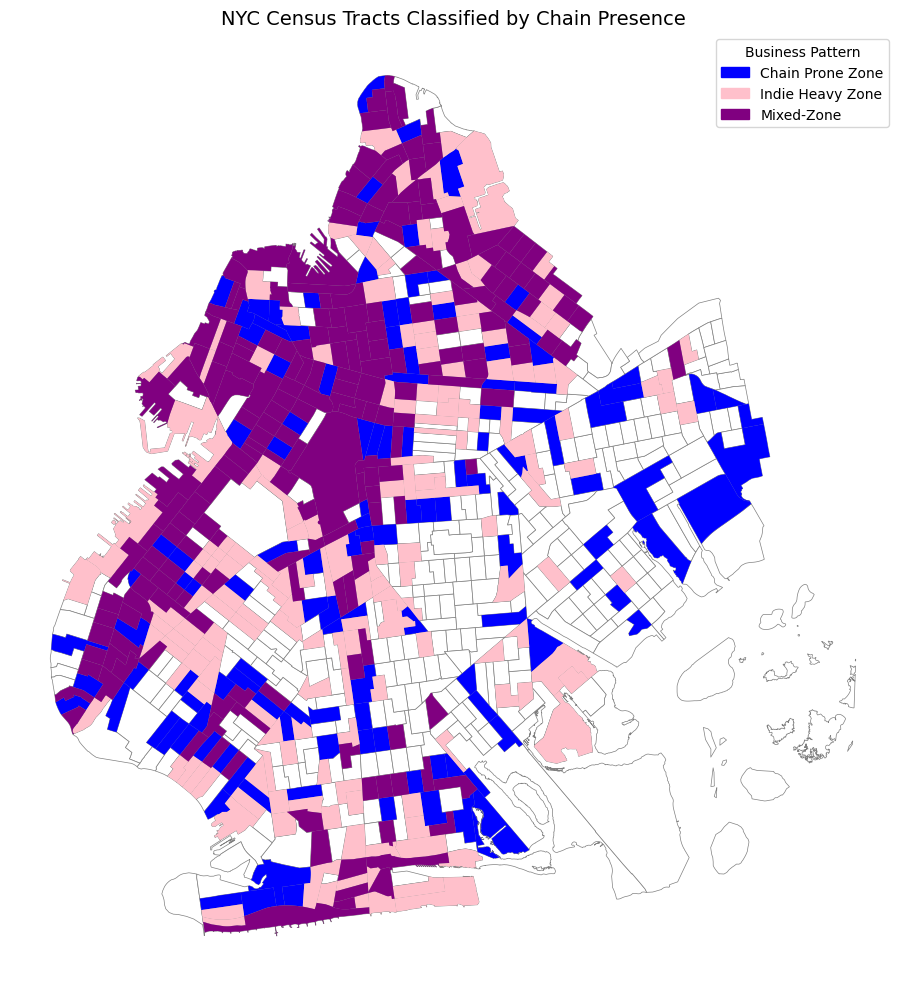

In [67]:
import matplotlib.patches as mpatches

nyc_clustered_ny = gpd.GeoDataFrame(nyc_clustered_ny, geometry='geometry', crs='EPSG:2263')

fig, ax = plt.subplots(figsize = (12,10))

nyct_ny.plot(ax=ax, edgecolor="grey", facecolor="white", linewidth=0.5)

for label, color in label_colors.items():
    nyc_clustered_ny[nyc_clustered_ny["cluster_label"] == label].plot(
        ax=ax,
        color=color,
        label=label.replace("_", " ").title(),
        edgecolor="none",
        linewidth=0
    )

legend_patches = [
    mpatches.Patch(color=color, label=label.replace("_", " ").title())
    for label, color in label_colors.items()
]
plt.legend(handles=legend_patches, title="Business Pattern")

plt.title("NYC Census Tracts Classified by Chain Presence", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [70]:
nyc_pois_new.columns

Index(['GEOID', 'total_pois', 'chain_count', 'indie_count', 'pct_chain',
       'pct_indie', 'CTLabel', 'BoroCode', 'BoroName', 'CT2020', 'BoroCT2020',
       'CDEligibil', 'NTAName', 'NTA2020', 'CDTA2020', 'CDTANAME', 'PUMA',
       'Shape_Leng', 'Shape_Area', 'geometry', 'NAME', 'B01003_001E',
       'B19013_001E', 'B17001_001E', 'B17001_002E', 'B23025_003E',
       'B23025_005E', 'B25003_001E', 'B25044_003E', 'B08301_001E',
       'B08301_010E', 'state', 'county', 'tract', 'total_population',
       'median_income', 'poverty_rate', 'unemployment_rate', 'no_vihicle_rate',
       'Agricultural_x', 'Commercial_x', 'Industrial_x', 'Institutional_x',
       'Natural_x', 'Open_Space_x', 'Residential_x', 'Agricultural_y',
       'Commercial_y', 'Industrial_y', 'Institutional_y', 'Natural_y',
       'Open_Space_y', 'Residential_y', 'Agricultural', 'Commercial',
       'Industrial', 'Institutional', 'Natural', 'Open_Space', 'Residential'],
      dtype='object')

# K-Means Cluster Analysis of NYC Census Tract Data

## Data organizing 

In [72]:
nyct_pois_df = pd.read_csv('C:/Users/ALIENWARE/Desktop/Machine Learning Final/nyc_pois_new.csv')
nyct_pois_df.head(2)

,Unnamed: 0,GEOID,total_pois,chain_count,indie_count,pct_chain,pct_indie,CTLabel,BoroCode,BoroName,...,B08301_001E,B08301_010E,state,county,tract,total_population,median_income,poverty_rate,unemployment_rate,no_vihicle_rate
0,0,36047000100,22,3,19,13.64,86.36,1.0,3,Brooklyn,...,2731.0,1206.0,36,47,100,4974.0,165188.0,4.573973,4.188122,22.101590
1,1,36047000200,14,2,12,14.29,85.71,2.0,3,Brooklyn,...,618.0,349.0,36,47,200,1170.0,78942.0,26.153846,7.500000,3.399433


In [73]:
nyct_pois_df["cluster_label"] = nyct_pois_df["pct_chain"].apply(classify_cluster)
nyct_pois_df.sample(5)

,Unnamed: 0,GEOID,total_pois,chain_count,indie_count,pct_chain,pct_indie,CTLabel,BoroCode,BoroName,...,B08301_010E,state,county,tract,total_population,median_income,poverty_rate,unemployment_rate,no_vihicle_rate,cluster_label
262,262,36047036600,5,1,4,20.00,80.00,366.00,3,Brooklyn,...,660.0,36,47,36600,4146.0,48075.0,30.175707,2.355460,6.114240,mixed-zone
337,337,36047048800,3,0,3,0.00,100.00,488.00,3,Brooklyn,...,822.0,36,47,48800,4472.0,72254.0,13.956670,6.713287,14.484007,indie_heavy zone
294,294,36047041401,1,0,1,0.00,100.00,414.01,3,Brooklyn,...,105.0,36,47,41401,1233.0,52750.0,26.034063,15.271967,17.441860,indie_heavy zone
315,315,36047043900,23,7,22,30.43,95.65,439.00,3,Brooklyn,...,915.0,36,47,43900,3390.0,71471.0,20.412979,15.160022,10.074627,mixed-zone
207,207,36047028300,1,0,1,0.00,100.00,283.00,3,Brooklyn,...,984.0,36,47,28300,4115.0,43254.0,32.822162,23.138431,3.887147,indie_heavy zone


In [74]:
nyct_pois_df = nyct_pois_df.dropna()

In [75]:
nyct_pois_df.columns

Index(['Unnamed: 0', 'GEOID', 'total_pois', 'chain_count', 'indie_count',
       'pct_chain', 'pct_indie', 'CTLabel', 'BoroCode', 'BoroName', 'CT2020',
       'BoroCT2020', 'CDEligibil', 'NTAName', 'NTA2020', 'CDTA2020',
       'CDTANAME', 'PUMA', 'Shape_Leng', 'Shape_Area', 'geometry', 'NAME',
       'B01003_001E', 'B19013_001E', 'B17001_001E', 'B17001_002E',
       'B23025_003E', 'B23025_005E', 'B25003_001E', 'B25044_003E',
       'B08301_001E', 'B08301_010E', 'state', 'county', 'tract',
       'total_population', 'median_income', 'poverty_rate',
       'unemployment_rate', 'no_vihicle_rate', 'cluster_label'],
      dtype='object')

In [76]:
nyct_pois_df = nyct_pois_df.drop(columns=["Unnamed: 0"], errors="ignore")

In [78]:
# Step 0: Ensure matching types
nyct_pois_df["GEOID"] = nyct_pois_df["GEOID"].astype(str)
nyct_ny["GEOID"] = nyct_ny["GEOID"].astype(str)

# Step 1: Project geometry to meters and calculate area in km²
nyct_ny_area = nyct_ny.set_index("GEOID").copy()
nyct_ny_area = nyct_ny_area.to_crs(epsg=6539)

In [79]:
# Step 1: Make sure tract area is in square kilometers
nyct_pois_df["tract_area_km2"] = nyct_ny.set_index("GEOID").loc[nyct_pois_df["GEOID"], "geometry"].to_crs(epsg=6539).area.values / 1e6

# Step 2: Normalize POI counts by area
nyct_pois_df["pois_per_km2"] = nyct_pois_df["total_pois"] / nyct_pois_df["tract_area_km2"]
nyct_pois_df["chain_per_km2"] = nyct_pois_df["chain_count"] / nyct_pois_df["tract_area_km2"]
nyct_pois_df["indie_per_km2"] = nyct_pois_df["indie_count"] / nyct_pois_df["tract_area_km2"]

In [80]:
nyct_pois_df

,GEOID,total_pois,chain_count,indie_count,pct_chain,pct_indie,CTLabel,BoroCode,BoroName,CT2020,...,total_population,median_income,poverty_rate,unemployment_rate,no_vihicle_rate,cluster_label,tract_area_km2,pois_per_km2,chain_per_km2,indie_per_km2
0,36047000100,22,3,19,13.64,86.36,1.00,3,Brooklyn,100,...,4974.0,165188.0,4.573973,4.188122,22.101590,mixed-zone,2.224166,9.891348,1.348820,8.542528
1,36047000200,14,2,12,14.29,85.71,2.00,3,Brooklyn,200,...,1170.0,78942.0,26.153846,7.500000,3.399433,mixed-zone,2.952085,4.742411,0.677487,4.064923
2,36047000301,3,2,1,66.67,33.33,3.01,3,Brooklyn,301,...,4057.0,193158.0,3.758829,2.440087,17.603393,chain_prone zone,2.164340,1.386104,0.924069,0.462035
3,36047000501,9,2,7,22.22,77.78,5.01,3,Brooklyn,501,...,4432.0,140795.0,6.352143,4.592241,37.110187,mixed-zone,0.901507,9.983283,2.218507,7.764776
4,36047000502,13,4,9,30.77,69.23,5.02,3,Brooklyn,502,...,2774.0,169313.0,4.286770,6.172840,28.766190,mixed-zone,1.041529,12.481649,3.840507,8.641142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,36047120803,1,1,0,100.00,0.00,1208.03,3,Brooklyn,120803,...,1951.0,72451.0,9.075440,0.927487,3.880071,chain_prone zone,1.665739,0.600334,0.600334,0.000000
506,36047122000,2,1,1,50.00,50.00,1220.00,3,Brooklyn,122000,...,7200.0,57055.0,21.291667,5.928293,0.000000,chain_prone zone,11.487203,0.174107,0.087053,0.087053
507,36047123700,6,0,6,0.00,100.00,1237.00,3,Brooklyn,123700,...,9448.0,51157.0,48.592295,4.347826,9.756098,indie_heavy zone,3.459462,1.734373,0.000000,1.734373
508,36047150200,2,0,2,0.00,100.00,1502.00,3,Brooklyn,150200,...,2730.0,128472.0,2.380952,3.356753,15.829384,indie_heavy zone,3.430774,0.582959,0.000000,0.582959


In [81]:
# Step 1: Ensure matching GEOID types
nyct_pois_df["GEOID"] = nyct_pois_df["GEOID"].astype(str)
nyct_ny["GEOID"] = nyct_ny["GEOID"].astype(str)

# Step 2: Select only land use columns from nyct_ny (including GEOID as key)
landuse_cols = ['GEOID', 'Agricultural', 'Commercial', 'Industrial', 'Institutional',
                'Natural', 'Open_Space', 'Residential']

landuse_only = nyct_ny[landuse_cols].copy()

# Step 3: Merge land use info into nyct_pois_df
nyct_pois_df = nyct_pois_df.merge(landuse_only, on="GEOID", how="left")

# Step 4: Optional – fill NaNs if needed
nyct_pois_df.fillna(0, inplace=True)

In [82]:
nyct_pois_df

,GEOID,total_pois,chain_count,indie_count,pct_chain,pct_indie,CTLabel,BoroCode,BoroName,CT2020,...,pois_per_km2,chain_per_km2,indie_per_km2,Agricultural,Commercial,Industrial,Institutional,Natural,Open_Space,Residential
0,36047000100,22,3,19,13.64,86.36,1.00,3,Brooklyn,100,...,9.891348,1.348820,8.542528,0.000000,0.000000,0.000000,0.0,0.023949,0.901416,0.074636
1,36047000200,14,2,12,14.29,85.71,2.00,3,Brooklyn,200,...,4.742411,0.677487,4.064923,0.000000,0.990826,0.009174,0.0,0.000000,0.000000,0.000000
2,36047000301,3,2,1,66.67,33.33,3.01,3,Brooklyn,301,...,1.386104,0.924069,0.462035,0.000000,0.000000,0.000000,0.0,0.187911,0.812089,0.000000
3,36047000501,9,2,7,22.22,77.78,5.01,3,Brooklyn,501,...,9.983283,2.218507,7.764776,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
4,36047000502,13,4,9,30.77,69.23,5.02,3,Brooklyn,502,...,12.481649,3.840507,8.641142,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,36047120803,1,1,0,100.00,0.00,1208.03,3,Brooklyn,120803,...,0.600334,0.600334,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.000000
497,36047122000,2,1,1,50.00,50.00,1220.00,3,Brooklyn,122000,...,0.174107,0.087053,0.087053,0.142443,0.000000,0.094531,0.0,0.292396,0.420320,0.050309
498,36047123700,6,0,6,0.00,100.00,1237.00,3,Brooklyn,123700,...,1.734373,0.000000,1.734373,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
499,36047150200,2,0,2,0.00,100.00,1502.00,3,Brooklyn,150200,...,0.582959,0.000000,0.582959,0.000000,0.000000,0.020627,0.0,0.000000,0.979373,0.000000


## Select Feature for inclusion in cluster analysis

In [89]:
cluster_df = nyct_pois_df[['pct_indie','poverty_rate','unemployment_rate','no_vihicle_rate','Residential']]
display(cluster_df)

,pct_indie,poverty_rate,unemployment_rate,no_vihicle_rate,Residential
0,86.36,4.573973,4.188122,22.101590,0.074636
1,85.71,26.153846,7.500000,3.399433,0.000000
2,33.33,3.758829,2.440087,17.603393,0.000000
3,77.78,6.352143,4.592241,37.110187,0.000000
4,69.23,4.286770,6.172840,28.766190,0.000000
...,...,...,...,...,...
496,0.00,9.075440,0.927487,3.880071,0.000000
497,50.00,21.291667,5.928293,0.000000,0.050309
498,100.00,48.592295,4.347826,9.756098,0.000000
499,100.00,2.380952,3.356753,15.829384,0.000000


In [90]:
# Scale features data to range between 0 and 1 with MinMaxScaler (as numpy array)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X = scaler.fit_transform(cluster_df)
display(pd.DataFrame(X,columns=cluster_df.columns))

,pct_indie,poverty_rate,unemployment_rate,no_vihicle_rate,Residential
0,0.43180,0.070524,0.105290,0.490509,0.074636
1,0.42855,0.424970,0.188550,0.075445,0.000000
2,0.16665,0.057136,0.061344,0.390679,0.000000
3,0.38890,0.099730,0.115449,0.823601,0.000000
4,0.34615,0.065807,0.155185,0.638419,0.000000
...,...,...,...,...,...
496,0.00000,0.144460,0.023317,0.086112,0.000000
497,0.25000,0.345109,0.149037,0.000000,0.050309
498,0.50000,0.793518,0.109304,0.216521,0.000000
499,0.50000,0.034504,0.084389,0.351308,0.000000


## Diagnistic texting for a defensible number of cluster

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

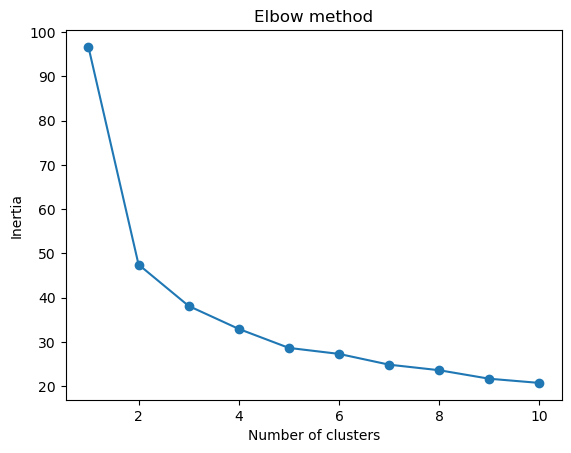

In [91]:
from sklearn.cluster import KMeans
inertias = []
for i in range(1,11):
    kmeans_elbow =  KMeans(n_clusters=i, n_init="auto")
    kmeans_elbow.fit(X)
    inertias.append(kmeans_elbow.inertia_)
plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show() 

## Running the final K-Mean cluster analysis

In [94]:
# Conduct the K-means analysis
# First defining a variable to control number of k categories
n_k = 4
from sklearn.cluster import KMeans
kmeans_model = KMeans(n_clusters=n_k, random_state=0, n_init="auto").fit(X)
# Display out cluster center means
display(pd.DataFrame(np.round(kmeans_model.cluster_centers_, decimals=4),columns=cluster_df.columns))

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,pct_indie,poverty_rate,unemployment_rate,no_vihicle_rate,Residential
0,0.3856,0.1784,0.1471,0.2447,0.0115
1,0.3505,0.2257,0.1499,0.1958,0.8970
2,0.4491,0.5329,0.2903,0.0903,0.9179
3,0.3679,0.4559,0.2207,0.1372,0.0065


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


[0 3 0 0 0 0 0 0 0 1 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 3 0 0 0 0 2 3 3 0 0 0 3 0 3 0 0 0 0 0 3 3 0 0 3 0 0 0 3 3 3 0 0 3 0 3
 3 3 0 3 0 3 0 3 3 1 3 0 0 0 0 3 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 1 3 1 0 1 0 1 1 0 1 1 0 1 0 3 0 3 0 1 0 0 0 0 0 3 0 0
 2 0 2 3 1 0 0 0 0 3 3 3 0 0 3 0 3 0 2 3 3 3 3 1 0 3 0 0 2 2 3 0 0 0 3 1 3
 1 0 1 3 0 0 0 0 0 0 3 0 3 0 2 0 3 3 3 2 2 0 2 3 0 3 3 3 0 3 3 3 3 0 3 0 2
 3 3 1 0 0 1 0 0 1 3 0 1 0 2 3 2 2 2 0 3 3 1 1 3 3 1 1 0 3 3 3 3 3 0 3 3 0
 0 3 1 0 0 3 1 2 3 0 3 3 0 3 3 0 0 3 3 0 0 3 0 3 0 3 0 3 0 3 3 2 3 2 3 3 3
 0 3 3 0 3 0 0 0 3 3 3 0 0 3 3 3 0 3 3 0 3 3 1 1 0 0 1 1 0 1 0 0 3 0 0 2 3
 2 0 3 0 0 0 0 0 0 0 0 0 0 2 0 3 3 3 3 0 3 0 3 0 0 3 0 0 0 0 0 3 2 3 0 0 2
 3 1 3 0 3 3 3 3 3 3 0 0 3 0 0 0 1 0 0 0 3 3 0 0 0 0 0 0 0 3 3 3 0 0 0 0 1
 1 0 0 0 1 0 0 0 1 3 0 0 0 3 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 0 0 0 3 0 0 0 3 0 0 0 3 3 0 0 0 0 0 3 0 3 3 3 3 2 3 3 2 1 0 0 3 3 3 0
 0 1 0 3 3 0 0 0 3 3 0 3 

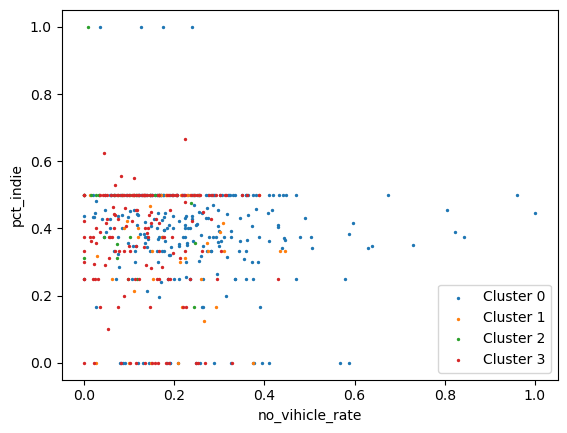

In [95]:
# Predict and visualize the clusters using pairs of features
# First make the predictions 
y_label = kmeans_model.fit_predict(X)
print(y_label)

# Then do some  looping to plot clusters for pairs of features 
columnx = 3
columny = 0
0
for i in range(0,n_k):
    plt.scatter(X[y_label==i, columnx], X[y_label==i, columny], s=2, label ='Cluster '+str(i))

plt.xlabel(cluster_df.columns[columnx])
plt.ylabel(cluster_df.columns[columny])
plt.legend(loc="lower right")
plt.show()

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


[0 3 0 0 0 0 0 0 0 1 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 3 0 0 0 0 2 3 3 0 0 0 3 0 3 0 0 0 0 0 3 3 0 0 3 0 0 0 3 3 3 0 0 3 0 3
 3 3 0 3 0 3 0 3 3 1 3 0 0 0 0 3 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 1 3 1 0 1 0 1 1 0 1 1 0 1 0 3 0 3 0 1 0 0 0 0 0 3 0 0
 2 0 2 3 1 0 0 0 0 3 3 3 0 0 3 0 3 0 2 3 3 3 3 1 0 3 0 0 2 2 3 0 0 0 3 1 3
 1 0 1 3 0 0 0 0 0 0 3 0 3 0 2 0 3 3 3 2 2 0 2 3 0 3 3 3 0 3 3 3 3 0 3 0 2
 3 3 1 0 0 1 0 0 1 3 0 1 0 2 3 2 2 2 0 3 3 1 1 3 3 1 1 0 3 3 3 3 3 0 3 3 0
 0 3 1 0 0 3 1 2 3 0 3 3 0 3 3 0 0 3 3 0 0 3 0 3 0 3 0 3 0 3 3 2 3 2 3 3 3
 0 3 3 0 3 0 0 0 3 3 3 0 0 3 3 3 0 3 3 0 3 3 1 1 0 0 1 1 0 1 0 0 3 0 0 2 3
 2 0 3 0 0 0 0 0 0 0 0 0 0 2 0 3 3 3 3 0 3 0 3 0 0 3 0 0 0 0 0 3 2 3 0 0 2
 3 1 3 0 3 3 3 3 3 3 0 0 3 0 0 0 1 0 0 0 3 3 0 0 0 0 0 0 0 3 3 3 0 0 0 0 1
 1 0 0 0 1 0 0 0 1 3 0 0 0 3 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 0 0 0 3 0 0 0 3 0 0 0 3 3 0 0 0 0 0 3 0 3 3 3 3 2 3 3 2 1 0 0 3 3 3 0
 0 1 0 3 3 0 0 0 3 3 0 3 

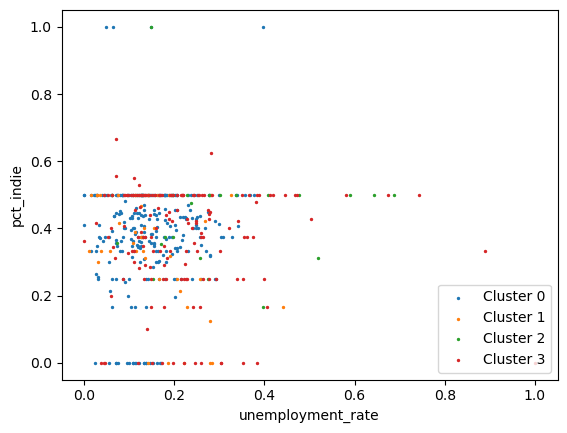

In [96]:
# Predict and visualize the clusters using pairs of features
# First make the predictions 
y_label = kmeans_model.fit_predict(X)
print(y_label)

# Then do some  looping to plot clusters for pairs of features 
columnx = 2
columny = 0
0
for i in range(0,n_k):
    plt.scatter(X[y_label==i, columnx], X[y_label==i, columny], s=2, label ='Cluster '+str(i))

plt.xlabel(cluster_df.columns[columnx])
plt.ylabel(cluster_df.columns[columny])
plt.legend(loc="lower right")
plt.show()

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


[0 3 0 0 0 0 0 0 0 1 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 3 0 0 0 0 2 3 3 0 0 0 3 0 3 0 0 0 0 0 3 3 0 0 3 0 0 0 3 3 3 0 0 3 0 3
 3 3 0 3 0 3 0 3 3 1 3 0 0 0 0 3 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 1 3 1 0 1 0 1 1 0 1 1 0 1 0 3 0 3 0 1 0 0 0 0 0 3 0 0
 2 0 2 3 1 0 0 0 0 3 3 3 0 0 3 0 3 0 2 3 3 3 3 1 0 3 0 0 2 2 3 0 0 0 3 1 3
 1 0 1 3 0 0 0 0 0 0 3 0 3 0 2 0 3 3 3 2 2 0 2 3 0 3 3 3 0 3 3 3 3 0 3 0 2
 3 3 1 0 0 1 0 0 1 3 0 1 0 2 3 2 2 2 0 3 3 1 1 3 3 1 1 0 3 3 3 3 3 0 3 3 0
 0 3 1 0 0 3 1 2 3 0 3 3 0 3 3 0 0 3 3 0 0 3 0 3 0 3 0 3 0 3 3 2 3 2 3 3 3
 0 3 3 0 3 0 0 0 3 3 3 0 0 3 3 3 0 3 3 0 3 3 1 1 0 0 1 1 0 1 0 0 3 0 0 2 3
 2 0 3 0 0 0 0 0 0 0 0 0 0 2 0 3 3 3 3 0 3 0 3 0 0 3 0 0 0 0 0 3 2 3 0 0 2
 3 1 3 0 3 3 3 3 3 3 0 0 3 0 0 0 1 0 0 0 3 3 0 0 0 0 0 0 0 3 3 3 0 0 0 0 1
 1 0 0 0 1 0 0 0 1 3 0 0 0 3 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 0 0 0 3 0 0 0 3 0 0 0 3 3 0 0 0 0 0 3 0 3 3 3 3 2 3 3 2 1 0 0 3 3 3 0
 0 1 0 3 3 0 0 0 3 3 0 3 

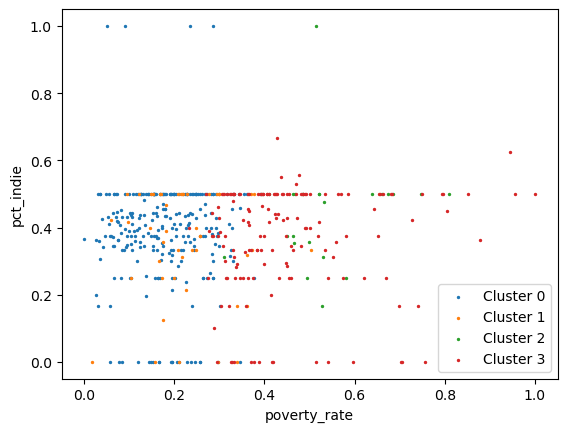

In [97]:
# Predict and visualize the clusters using pairs of features
# First make the predictions 
y_label = kmeans_model.fit_predict(X)
print(y_label)

# Then do some  looping to plot clusters for pairs of features 
columnx = 1
columny = 0
0
for i in range(0,n_k):
    plt.scatter(X[y_label==i, columnx], X[y_label==i, columny], s=2, label ='Cluster '+str(i))

plt.xlabel(cluster_df.columns[columnx])
plt.ylabel(cluster_df.columns[columny])
plt.legend(loc="lower right")
plt.show()

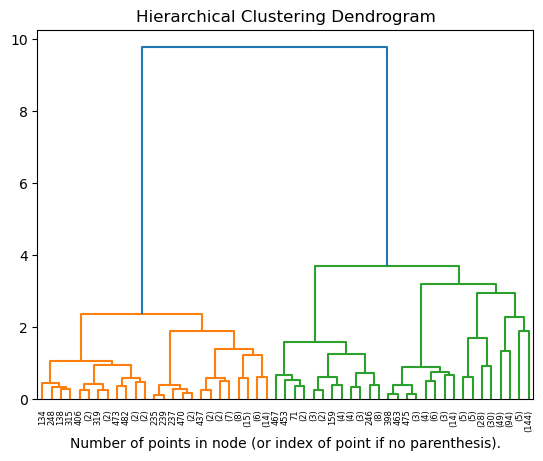

In [98]:
# Visualize the tree (dendrogram) for this data
from sklearn.cluster import AgglomerativeClustering
agglom_model = AgglomerativeClustering(distance_threshold=0,n_clusters=None)
agglom_model = agglom_model.fit(X)

from scipy.cluster.hierarchy import dendrogram
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(agglom_model, truncate_mode="level", p=5)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

# RandomForest Classifier


Classification Report:
                  precision    recall  f1-score   support

chain_prone zone       0.26      0.16      0.20        32
indie_heavy zone       0.36      0.37      0.37        43
      mixed-zone       0.52      0.65      0.58        51

        accuracy                           0.43       126
       macro avg       0.38      0.39      0.38       126
    weighted avg       0.40      0.43      0.41       126

Confusion Matrix:


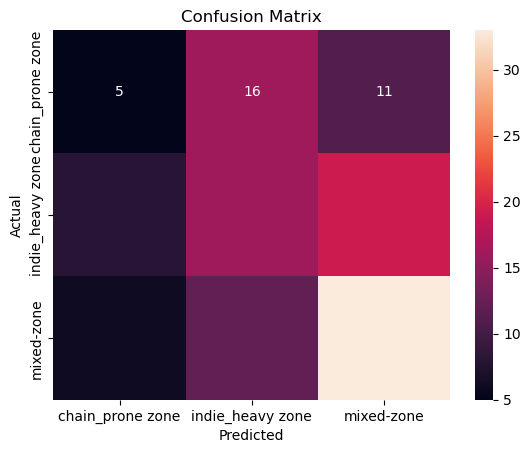

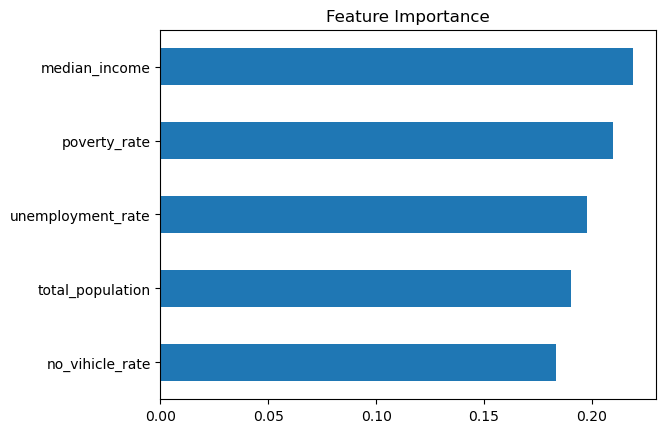

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define features and target
features = [
    "total_population",
    "median_income",
    "poverty_rate",
    "unemployment_rate",
    "no_vihicle_rate"
]

X = nyct_pois_df[features]
y = nyct_pois_df["cluster_label"]  # Make sure this column has the 3 categories

# Optional: drop rows with missing values
X = X.dropna()
y = y.loc[X.index]

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 4. Prediction and Evaluation
y_pred = clf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 5. Feature importance
importances = pd.Series(clf.feature_importances_, index=features)
importances.sort_values().plot(kind="barh", title="Feature Importance")
plt.show()